✅ Dataset loaded successfully
✅ Preprocessing complete. Dataset shape: (265, 3)
📊 Train size: 212, Test size: 53

🚀 BASELINE TIME SERIES FORECASTING MODELS

🔵 BASELINE ARIMA MODEL

📌 Parameters: p=1, d=1, q=1

📊 Performance Metrics:
   MAE: 117.4066
   MSE: 16925.8197
   RMSE: 130.0993
   MAPE: 54.8244
   sMAPE: 77.6510
   MASE: 5.6187
   R²: -4.0722
   AIC: 2004.6396
   BIC: 2014.6952
   Execution_Time: 0.1500


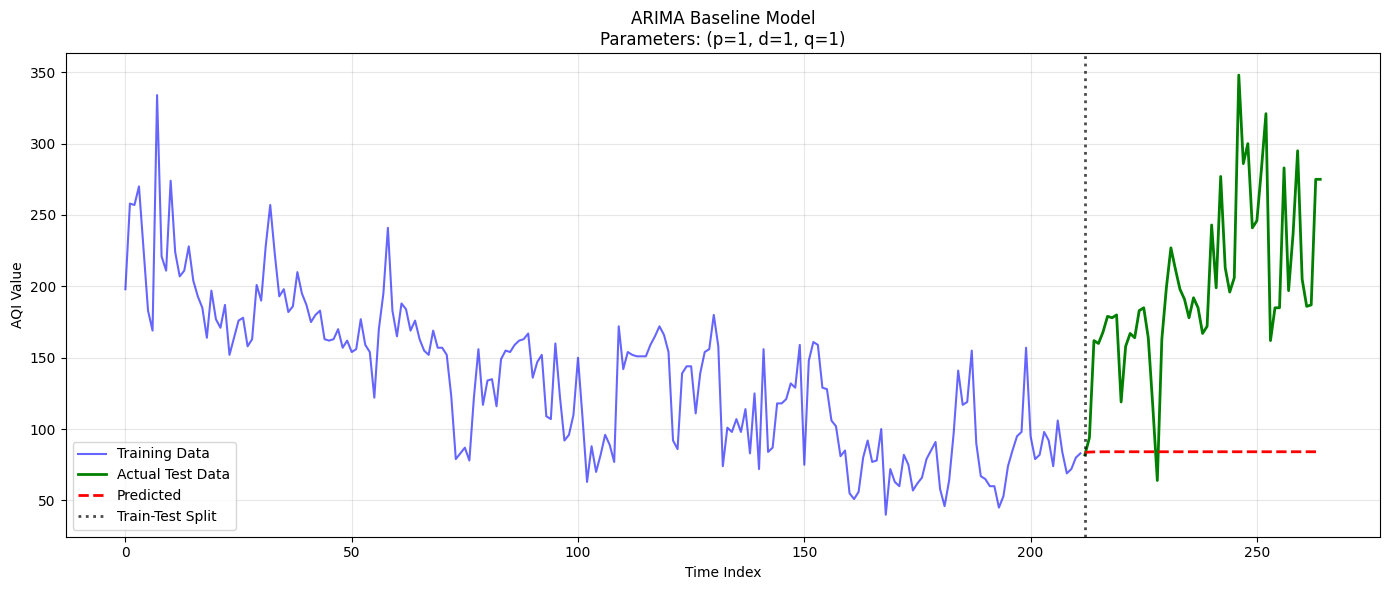

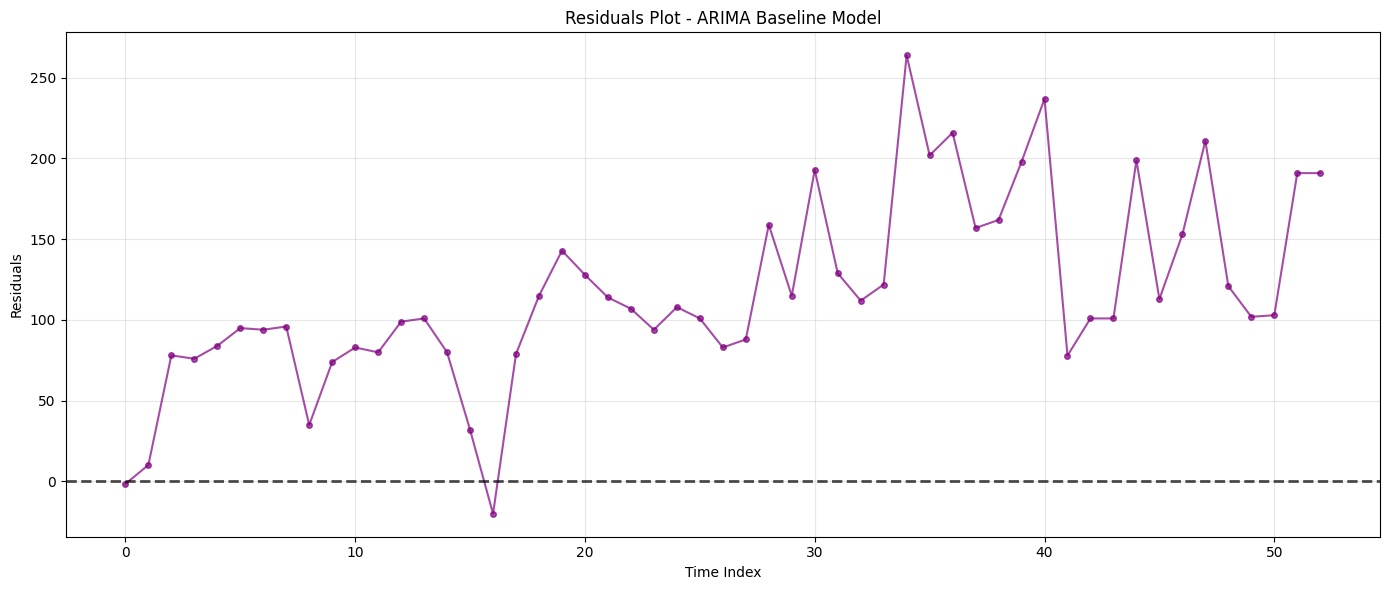


🟢 BASELINE SARIMA MODEL

📌 Parameters:
   Order: (p=1, d=1, q=1)
   Seasonal Order: (P=1, D=1, Q=1, s=12)

📊 Performance Metrics:
   MAE: 145.7420
   MSE: 25462.3029
   RMSE: 159.5691
   MAPE: 68.5386
   sMAPE: 108.6206
   MASE: 6.9747
   R²: -6.6303
   AIC: 1749.9160
   BIC: 1766.0178
   Execution_Time: 0.7896


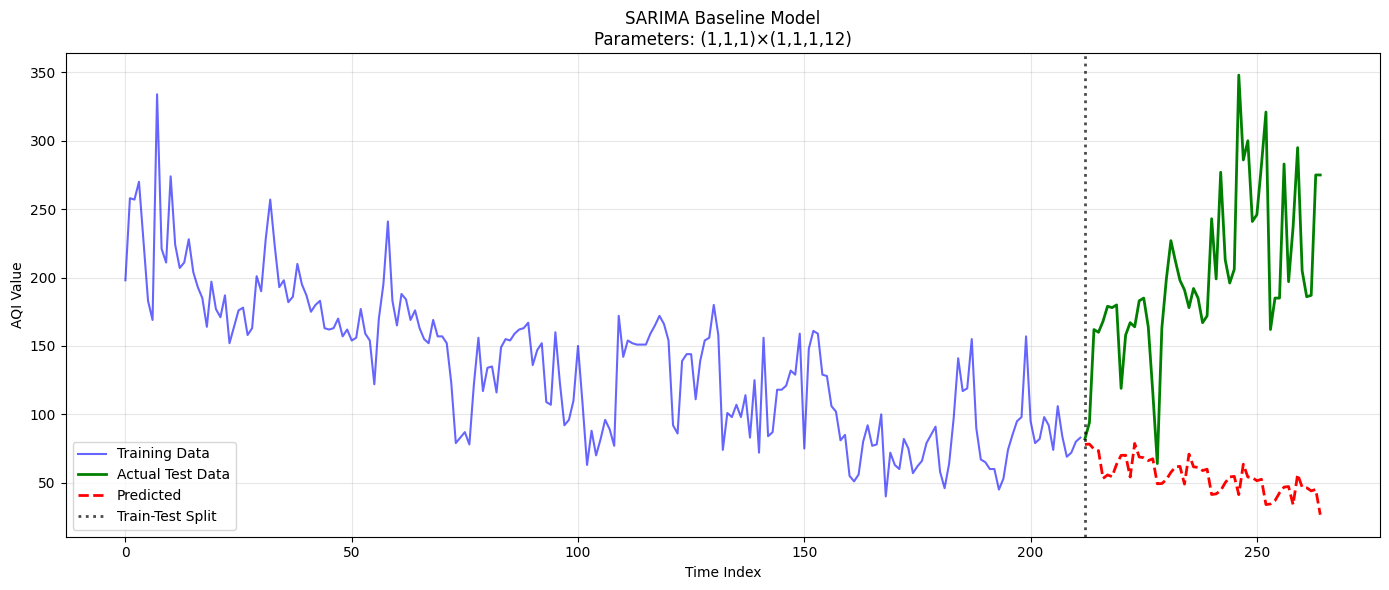

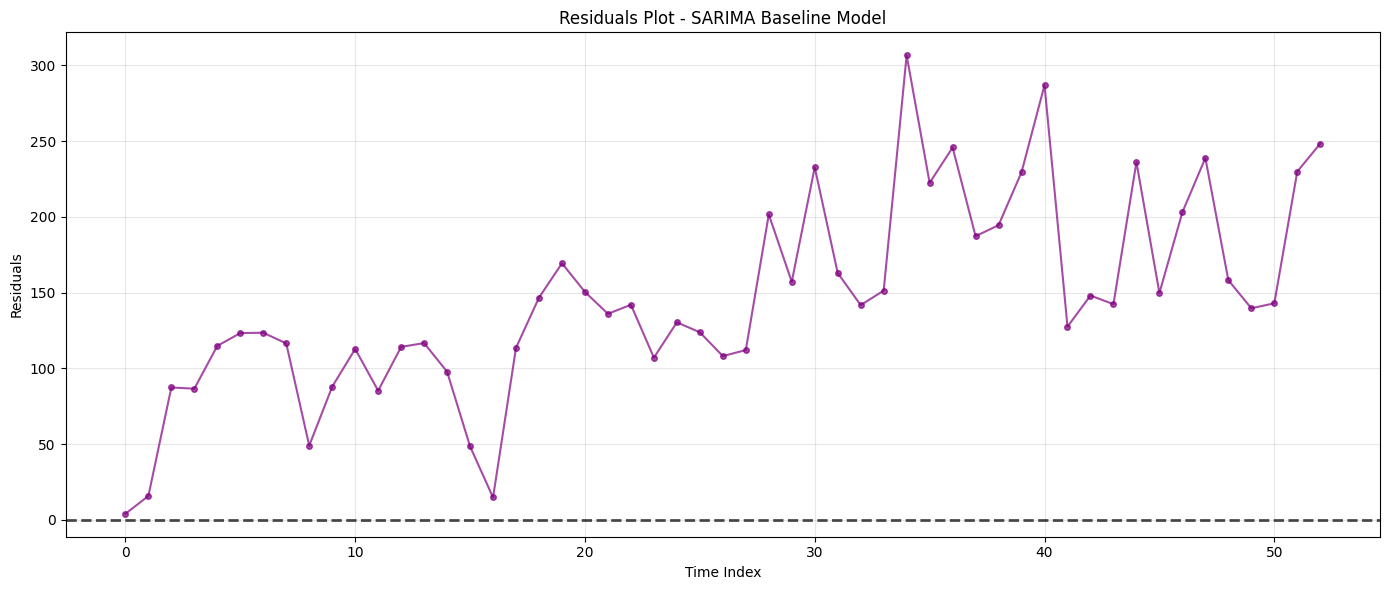


🟡 BASELINE ETS (EXPONENTIAL SMOOTHING) MODEL

📌 Parameters:
   Trend: add
   Seasonal: add
   Seasonal Periods: 12

📊 Performance Metrics:
   MAE: 145.8471
   MSE: 25725.9656
   RMSE: 160.3932
   MAPE: 68.3812
   sMAPE: 108.7047
   MASE: 6.9798
   R²: -6.7093
   AIC: 1418.2084
   BIC: 1471.9138
   Execution_Time: 0.1749


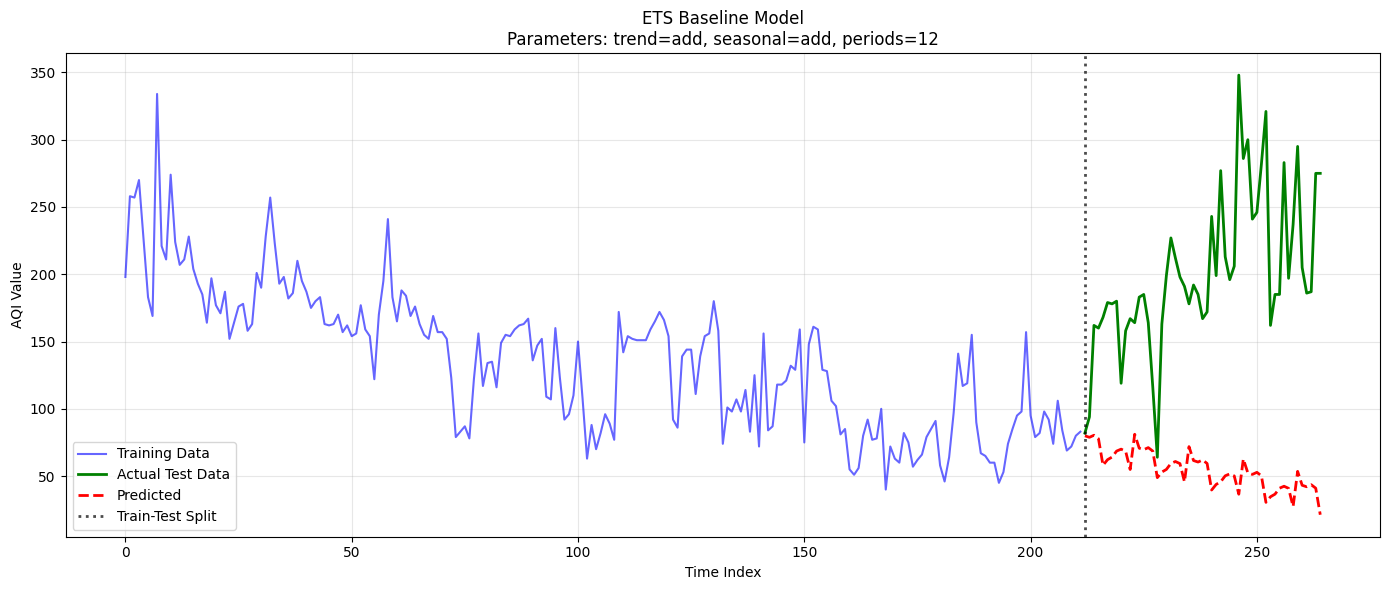

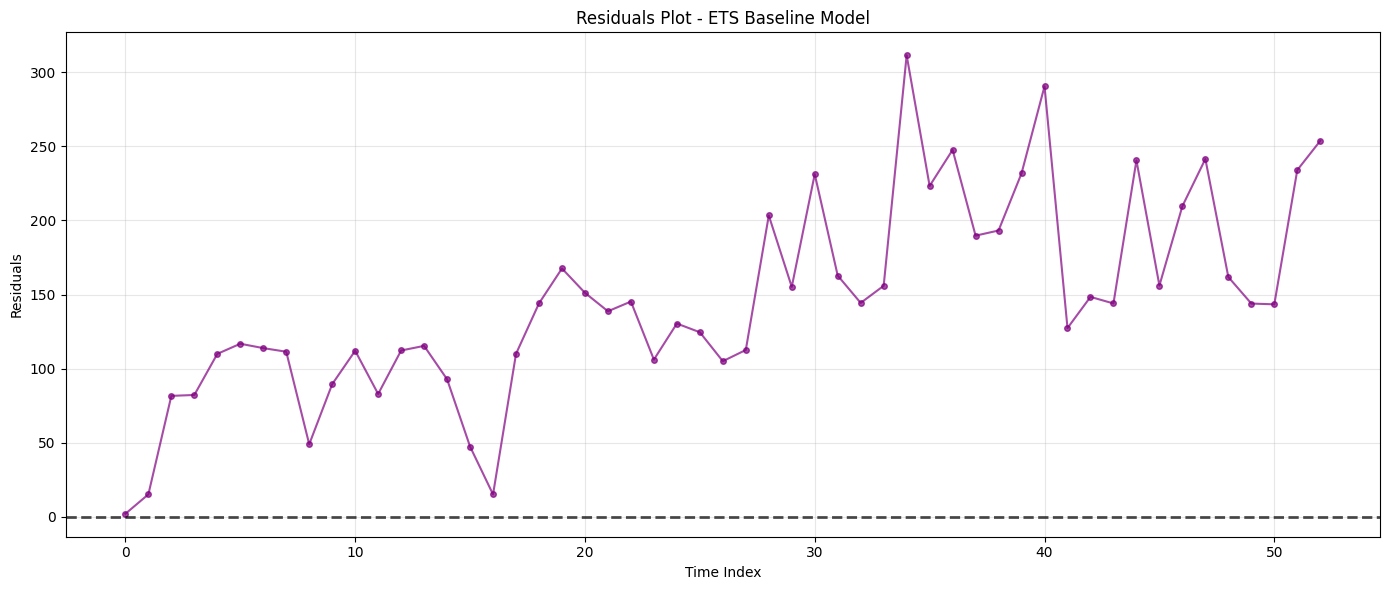


📋 BASELINE MODELS COMPARISON

  Model                          Parameters       RMSE        MAE      MAPE      sMAPE     MASE        R²         AIC         BIC  Time (s)
 ARIMA                             (1,1,1) 130.099269 117.406641 54.824444  77.650995 5.618689 -4.072162 2004.639646 2014.695221  0.149993
SARIMA                  (1,1,1)×(1,1,1,12) 159.569116 145.741969 68.538618 108.620585 6.974723 -6.630290 1749.916035 1766.017814  0.789616
   ETS trend=add, seasonal=add, periods=12 160.393159 145.847063 68.381211 108.704684 6.979753 -6.709302 1418.208440 1471.913820  0.174867

🏆 Best Baseline Model: ARIMA (RMSE: 130.0993)


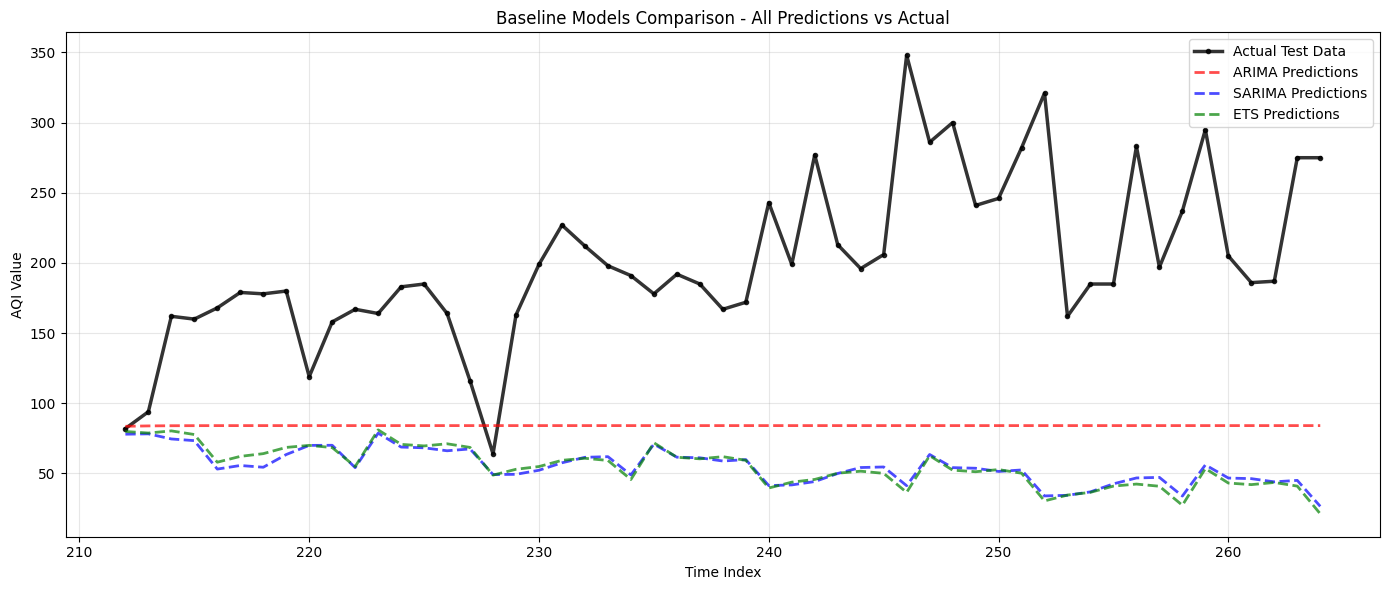


✅ Results saved to 'baseline_models_comparison.csv'

✅ BASELINE FORECASTING COMPLETE


In [1]:
"""
Baseline Time Series Forecasting Models
ARIMA, SARIMA, and ETS with Standard Parameters
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

# ================== DATA LOADING ==================
file_path = "/kaggle/input/rampal-aqi/Rampal_AQI _2.csv"

try:
    df = pd.read_csv(file_path)
    print("✅ Dataset loaded successfully")
except FileNotFoundError:
    print(f"❌ File not found at: {file_path}")
    exit()

# ================== PREPROCESSING ==================
def format_date(date_str):
    """Format date to MM/DD/YYYY"""
    parts = date_str.split('/')
    month = parts[0].zfill(2)
    day = parts[1].zfill(2)
    year = parts[2]
    return f"{month}/{day}/{year}"

# Apply date formatting
df['Date'] = df['Date'].apply(format_date)

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# Sort by date
df = df.sort_values(by='Date')

# Remove DNA values
df = df[df['AQI'] != 'DNA']
df['AQI'] = pd.to_numeric(df['AQI'], errors='coerce')
df = df.dropna(subset=['AQI'])

print(f"✅ Preprocessing complete. Dataset shape: {df.shape}")

# ================== TRAIN-TEST SPLIT ==================
train_size = int(len(df) * 0.8)
train_df = df[:train_size]
test_df = df[train_size:]

y_train = train_df['AQI'].values
y_test = test_df['AQI'].values

print(f"📊 Train size: {len(y_train)}, Test size: {len(y_test)}")

# ================== METRICS CALCULATION ==================
def calculate_metrics(y_true, y_pred, y_train, exec_time, aic=None, bic=None):
    """Calculate comprehensive evaluation metrics"""
    
    # Basic metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # MAPE (Mean Absolute Percentage Error)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    
    # sMAPE (Symmetric MAPE)
    smape = np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-10)) * 100
    
    # MASE (Mean Absolute Scaled Error)
    naive_forecast = np.roll(y_train, 1)[1:]
    mae_naive = np.mean(np.abs(y_train[1:] - naive_forecast))
    mase = mae / (mae_naive + 1e-10)
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'sMAPE': smape,
        'MASE': mase,
        'R²': r2,
        'AIC': aic if aic is not None else np.nan,
        'BIC': bic if bic is not None else np.nan,
        'Execution_Time': exec_time
    }

# ================== VISUALIZATION FUNCTIONS ==================
def plot_predictions(y_train, y_test, y_pred, model_name, params_str):
    """Plot training data and predictions with train-test split line"""
    plt.figure(figsize=(14, 6))
    
    # Plot training data
    plt.plot(range(len(y_train)), y_train, label='Training Data', color='blue', alpha=0.6)
    
    # Plot test data
    test_start = len(y_train)
    plt.plot(range(test_start, test_start + len(y_test)), y_test,
             label='Actual Test Data', color='green', linewidth=2)
    
    # Plot predictions
    plt.plot(range(test_start, test_start + len(y_pred)), y_pred,
             label='Predicted', color='red', linestyle='--', linewidth=2)
    
    # Add vertical line for train-test split
    plt.axvline(x=test_start, color='black', linestyle=':', linewidth=2, 
                label='Train-Test Split', alpha=0.7)
    
    plt.title(f'{model_name} Baseline Model\nParameters: {params_str}')
    plt.xlabel('Time Index')
    plt.ylabel('AQI Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_residuals(y_test, y_pred, model_name):
    """Plot residuals"""
    plt.figure(figsize=(14, 6))
    
    residuals = y_test - y_pred
    plt.plot(range(len(residuals)), residuals, color='purple', marker='o', 
             markersize=4, linestyle='-', alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7)
    
    plt.title(f'Residuals Plot - {model_name} Baseline Model')
    plt.xlabel('Time Index')
    plt.ylabel('Residuals')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ================== BASELINE ARIMA MODEL ==================
def baseline_arima(y_train, y_test):
    """
    Baseline ARIMA Model with standard parameters (1,1,1)
    """
    print("\n" + "="*60)
    print("🔵 BASELINE ARIMA MODEL")
    print("="*60)
    
    # Baseline parameters
    p, d, q = 1, 1, 1
    
    start_time = time.time()
    
    try:
        # Fit ARIMA model
        model = ARIMA(y_train, order=(p, d, q))
        model_fit = model.fit()
        
        # Make predictions
        y_pred = model_fit.forecast(steps=len(y_test))
        
        execution_time = time.time() - start_time
        
        # Get AIC and BIC
        aic = model_fit.aic
        bic = model_fit.bic
        
        # Calculate metrics
        metrics = calculate_metrics(y_test, y_pred, y_train, execution_time, aic, bic)
        
        # Print results
        print(f"\n📌 Parameters: p={p}, d={d}, q={q}")
        print(f"\n📊 Performance Metrics:")
        for metric, value in metrics.items():
            print(f"   {metric}: {value:.4f}")
        
        # Plot predictions
        plot_predictions(y_train, y_test, y_pred, "ARIMA", f"(p={p}, d={d}, q={q})")
        
        # Plot residuals
        plot_residuals(y_test, y_pred, "ARIMA")
        
        return {
            'model': 'ARIMA',
            'params': f"({p},{d},{q})",
            'predictions': y_pred,
            'metrics': metrics
        }
        
    except Exception as e:
        print(f"❌ Error in ARIMA model: {str(e)}")
        return None

# ================== BASELINE SARIMA MODEL ==================
def baseline_sarima(y_train, y_test):
    """
    Baseline SARIMA Model with standard parameters
    Order: (1,1,1), Seasonal Order: (1,1,1,12)
    """
    print("\n" + "="*60)
    print("🟢 BASELINE SARIMA MODEL")
    print("="*60)
    
    # Baseline parameters
    p, d, q = 1, 1, 1
    P, D, Q, s = 1, 1, 1, 12
    
    start_time = time.time()
    
    try:
        # Fit SARIMA model
        model = SARIMAX(y_train, 
                       order=(p, d, q),
                       seasonal_order=(P, D, Q, s),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
        model_fit = model.fit(disp=False)
        
        # Make predictions
        y_pred = model_fit.forecast(steps=len(y_test))
        
        execution_time = time.time() - start_time
        
        # Get AIC and BIC
        aic = model_fit.aic
        bic = model_fit.bic
        
        # Calculate metrics
        metrics = calculate_metrics(y_test, y_pred, y_train, execution_time, aic, bic)
        
        # Print results
        print(f"\n📌 Parameters:")
        print(f"   Order: (p={p}, d={d}, q={q})")
        print(f"   Seasonal Order: (P={P}, D={D}, Q={Q}, s={s})")
        print(f"\n📊 Performance Metrics:")
        for metric, value in metrics.items():
            print(f"   {metric}: {value:.4f}")
        
        # Plot predictions
        plot_predictions(y_train, y_test, y_pred, "SARIMA", 
                        f"({p},{d},{q})×({P},{D},{Q},{s})")
        
        # Plot residuals
        plot_residuals(y_test, y_pred, "SARIMA")
        
        return {
            'model': 'SARIMA',
            'params': f"({p},{d},{q})×({P},{D},{Q},{s})",
            'predictions': y_pred,
            'metrics': metrics
        }
        
    except Exception as e:
        print(f"❌ Error in SARIMA model: {str(e)}")
        return None

# ================== BASELINE ETS MODEL ==================
def baseline_ets(y_train, y_test):
    """
    Baseline ETS Model with standard parameters
    Trend: additive, Seasonal: additive, Period: 12
    """
    print("\n" + "="*60)
    print("🟡 BASELINE ETS (EXPONENTIAL SMOOTHING) MODEL")
    print("="*60)
    
    # Baseline parameters
    trend = 'add'
    seasonal = 'add'
    seasonal_periods = 12
    
    start_time = time.time()
    
    try:
        # Fit ETS model
        model = ExponentialSmoothing(
            y_train,
            trend=trend,
            seasonal=seasonal,
            seasonal_periods=seasonal_periods
        )
        model_fit = model.fit()
        
        # Make predictions
        y_pred = model_fit.forecast(steps=len(y_test))
        
        execution_time = time.time() - start_time
        
        # Get AIC and BIC
        aic = model_fit.aic
        bic = model_fit.bic
        
        # Calculate metrics
        metrics = calculate_metrics(y_test, y_pred, y_train, execution_time, aic, bic)
        
        # Print results
        print(f"\n📌 Parameters:")
        print(f"   Trend: {trend}")
        print(f"   Seasonal: {seasonal}")
        print(f"   Seasonal Periods: {seasonal_periods}")
        print(f"\n📊 Performance Metrics:")
        for metric, value in metrics.items():
            print(f"   {metric}: {value:.4f}")
        
        # Plot predictions
        plot_predictions(y_train, y_test, y_pred, "ETS", 
                        f"trend={trend}, seasonal={seasonal}, periods={seasonal_periods}")
        
        # Plot residuals
        plot_residuals(y_test, y_pred, "ETS")
        
        return {
            'model': 'ETS',
            'params': f"trend={trend}, seasonal={seasonal}, periods={seasonal_periods}",
            'predictions': y_pred,
            'metrics': metrics
        }
        
    except Exception as e:
        print(f"❌ Error in ETS model: {str(e)}")
        return None

# ================== MAIN EXECUTION ==================
if __name__ == "__main__":
    
    print("\n" + "="*60)
    print("🚀 BASELINE TIME SERIES FORECASTING MODELS")
    print("="*60)
    
    # Store results
    results = []
    
    # Run ARIMA baseline
    arima_result = baseline_arima(y_train, y_test)
    if arima_result:
        results.append(arima_result)
    
    # Run SARIMA baseline
    sarima_result = baseline_sarima(y_train, y_test)
    if sarima_result:
        results.append(sarima_result)
    
    # Run ETS baseline
    ets_result = baseline_ets(y_train, y_test)
    if ets_result:
        results.append(ets_result)
    
    # ================== COMPARISON TABLE ==================
    print("\n" + "="*60)
    print("📋 BASELINE MODELS COMPARISON")
    print("="*60)
    
    if results:
        comparison_df = pd.DataFrame([
            {
                'Model': r['model'],
                'Parameters': r['params'],
                'RMSE': r['metrics']['RMSE'],
                'MAE': r['metrics']['MAE'],
                'MAPE': r['metrics']['MAPE'],
                'sMAPE': r['metrics']['sMAPE'],
                'MASE': r['metrics']['MASE'],
                'R²': r['metrics']['R²'],
                'AIC': r['metrics']['AIC'],
                'BIC': r['metrics']['BIC'],
                'Time (s)': r['metrics']['Execution_Time']
            }
            for r in results
        ])
        
        print("\n", comparison_df.to_string(index=False))
        
        # Find best model based on RMSE
        best_idx = comparison_df['RMSE'].idxmin()
        best_model = comparison_df.loc[best_idx, 'Model']
        best_rmse = comparison_df.loc[best_idx, 'RMSE']
        
        print(f"\n🏆 Best Baseline Model: {best_model} (RMSE: {best_rmse:.4f})")
        
        # ================== VISUALIZATION: COMPARISON PLOT ==================
        plt.figure(figsize=(14, 6))
        
        test_start = len(y_train)
        
        # Plot actual test data
        plt.plot(range(test_start, test_start + len(y_test)), y_test,
                label='Actual Test Data', color='black', linewidth=2.5, marker='o', 
                markersize=3, alpha=0.8)
        
        # Plot predictions from all models
        colors = ['red', 'blue', 'green']
        for i, r in enumerate(results):
            plt.plot(range(test_start, test_start + len(r['predictions'])), 
                    r['predictions'],
                    label=f"{r['model']} Predictions", 
                    linestyle='--', 
                    linewidth=2,
                    color=colors[i],
                    alpha=0.7)
        
        plt.title('Baseline Models Comparison - All Predictions vs Actual')
        plt.xlabel('Time Index')
        plt.ylabel('AQI Value')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # ================== SAVE RESULTS ==================
        # Save comparison table to CSV
        comparison_df.to_csv('baseline_models_comparison.csv', index=False)
        print("\n✅ Results saved to 'baseline_models_comparison.csv'")
        
    else:
        print("\n❌ No models successfully completed")
    
    print("\n" + "="*60)
    print("✅ BASELINE FORECASTING COMPLETE")
    print("="*60)